<a href="https://colab.research.google.com/github/jceltruda/Projects-in-AI-and-ML/blob/main/Project_4/ML_AI_Projects_4_Task_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###**Task 2**

* Problem: Predict future weather conditions using

* Dataset: https://www.kaggle.com/datasets/alistairking/weather-long-term-time-series-forecasting

* Why sequence models are needed:

  This data violates the assumption that data is i.i.d. since there is heavy dependence/correlation between data points. The temperature at one point is dependant on the previous data point, these are not independant. We need to use a model which accounts for this, RNNs process data sequentially, allowing them to identify patterns and relate each new data point to the previous ones.

**Task 2: Parts 1 & 2**

In [ ]:
!pip install kagglehub

In [ ]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

file_path = "cleaned_weather.csv"
# Load dataset
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "alistairking/weather-long-term-time-series-forecasting",
  file_path,
)

print("First 5 records:", df.head())
print(df.shape)

/tmp/ipykernel_469/4283370284.py:6: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'weather-long-term-time-series-forecasting' dataset.
First 5 records:                   date        p     T    Tpot  Tdew    rh  VPmax  VPact  \
0  2020-01-01 00:10:00  1008.89  0.71  273.18 -1.33  86.1   6.43   5.54   
1  2020-01-01 00:20:00  1008.76  0.75  273.22 -1.44  85.2   6.45   5.49   
2  2020-01-01 00:30:00  1008.66  0.73  273.21 -1.48  85.1   6.44   5.48   
3  2020-01-01 00:40:00  1008.64  0.37  272.86 -1.64  86.3   6.27   5.41   
4  2020-01-01 00:50:00  1008.61  0.33  272.82 -1.50  87.4   6.26   5.47   

   VPdef    sh  ...      rho    wv  max. wv     wd  rain  raining  SWDR  PAR  \
0   0.89  3.42  ...  1280.62  1.02     1.60  224.3   0.0      0.0   0.0  0.0   
1   0.95  3.39  ...  1280.33  0.43     0.84  206.8   0.0      0.0   0.0  0.0   
2   0.96  3.39  ...  1280.29  0.61     1.48  197.1   0.0      0.0   0.0  0.0   
3   0.86  3.35  ...  1281.97  1.11     1.48  206.4   0.0      0.0   0.0  0.0   
4   0.79  3.38  ...  1282.08  0.49  

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from torch.utils.data import DataLoader, TensorDataset

# Preprocess dataset
data = df['T'].values.reshape(-1, 1) # Target variable is temperature
# Normalize
scaler = MinMaxScaler(feature_range=(-1, 1))
data_normalized = scaler.fit_transform(data)

# Create sequences
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:(i + seq_length)])
        y.append(data[i + seq_length])
    return torch.tensor(X, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)

seq_length = 24 # Look back 24 hours
X, y = create_sequences(data_normalized, seq_length)

# Train, test, val split
train_size = int(len(X) * 0.7)
val_size = int(len(X) * 0.15)

X_train, y_train = X[:train_size], y[:train_size]
X_val, y_val = X[train_size:train_size+val_size], y[train_size:train_size+val_size]
X_test, y_test = X[train_size+val_size:], y[train_size+val_size:]

train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=32, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=32, shuffle=False)

In [ ]:
# Model Implementations
import torch.nn as nn

class RNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(RNN, self).__init__()
        self.hidden_size = hidden_size
        self.rnn = nn.RNN(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        rnn_out, hn = self.rnn(x)
        # Use final time step as output
        out = self.fc(rnn_out[:, -1, :])
        return out

class LSTM(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(LSTM, self).__init__()
        self.hidden_size = hidden_size
        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        rnn_out, (hn, cn) = self.lstm(x)
        # Use final time step as output
        out = self.fc(rnn_out[:, -1, :])
        return out

class GRU(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(GRU, self).__init__()
        self.hidden_size = hidden_size
        self.gru = nn.GRU(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        rnn_out, hn = self.gru(x)
        # Use final time step as output
        out = self.fc(rnn_out[:, -1, :])
        return out

My RNN is implemented using PyTorch's nn.RNN. My model has one hidden layer with 64 nodes. I use the tanh activation at each time step and a linear activation (fully connected layer) for the output. Tanh prevents hiddent states from growing too large and the output handles the regression task of predicting the temperature value.

I will use mean squared error to measure the performance of my model. This will help reduce large errors since it penalizes them more.

In [ ]:
# Training
def train_and_evaluate(model, model_name, epochs=50):
    criterion = nn.MSELoss() # Metric: mean squared error
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    train_losses, val_losses = [], []

    for epoch in range(epochs):
        model.train()
        epoch_train_loss = 0
        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()
            epoch_train_loss += loss.item()

        # Validation
        model.eval()
        epoch_val_loss = 0
        with torch.no_grad():
            for batch_X, batch_y in val_loader:
                outputs = model(batch_X)
                loss = criterion(outputs, batch_y)
                epoch_val_loss += loss.item()

        train_losses.append(epoch_train_loss / len(train_loader))
        val_losses.append(epoch_val_loss / len(val_loader))

    # Final test set evaluation
    model.eval()
    with torch.no_grad():
        test_predictions = model(X_test)
        test_loss = criterion(test_predictions, y_test).item()

    print(f"{model_name} - Test MSE: {test_loss:.4f}")
    return train_losses, val_losses

Training models...
RNN - Test MSE: 0.0001
LSTM - Test MSE: 0.0000
GRU - Test MSE: 0.0001


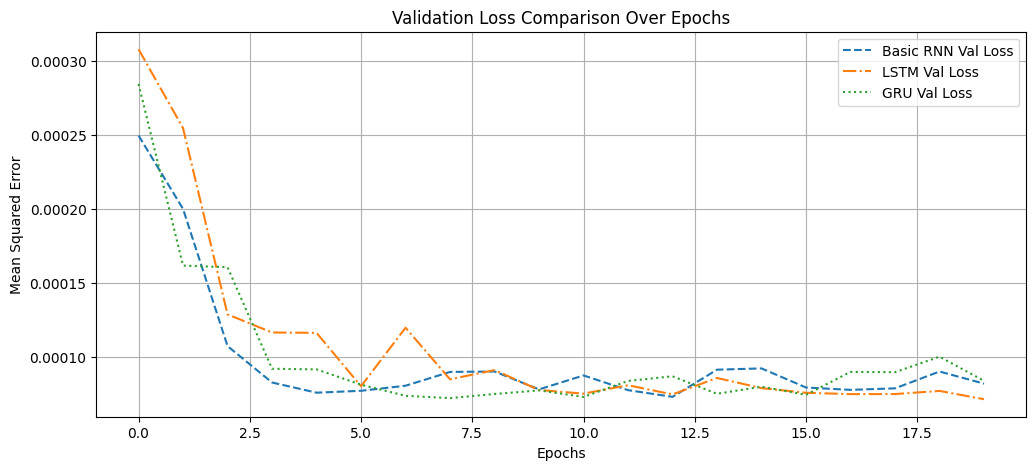

In [ ]:
# Print results
print("Training models...")

# Define hyperparameters
input_size = 1
hidden_size = 64
output_size = 1

# Define models
rnn = RNN(input_size, hidden_size, output_size)
lstm = LSTM(input_size, hidden_size, output_size)
gru = GRU(input_size, hidden_size, output_size)

# Train
rnn_train, rnn_val = train_and_evaluate(rnn, 'RNN', epochs=20)
lstm_train, lstm_val = train_and_evaluate(lstm, 'LSTM', epochs=20)
gru_train, gru_val = train_and_evaluate(gru, 'GRU', epochs=20)

# Plot results
plt.figure(figsize=(12, 5))
plt.plot(rnn_val, label='Basic RNN Val Loss', linestyle='--')
plt.plot(lstm_val, label='LSTM Val Loss', linestyle='-.')
plt.plot(gru_val, label='GRU Val Loss', linestyle=':')
plt.title('Validation Loss Comparison Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error')
plt.legend()
plt.grid(True)
plt.show()

I don't notice many "major" differences, as all models converge around 5 epochs. The LSTM started with the highest loss, and its loss function oscillated more during the first 7.5 epochs, with loss spiking and then coming back down. The RNN and GRU are similar, with the RNN generally performing better in the first 5 epochs and last 2.5 epochs.

The LSTM ultimately acheives the lowest loss, which is likely due to its more complex internal cell state which allow it to learn deeper relationships. The RNN and GRU use more simplier approaches, which allow them to learn a similar level of complexity from this dataset.

**Task 2: Part 3**

Yes, we could alter our approach to the problem to use a feed-forward network to solve this. This would require converting our time-series data points to form one vector per designated time period. This would treat each time period as a single data point which could be used by the feed-forward network.

This is a worse approach for this problem, as it makes it more difficult for the model to learn seasonal (long-term) patterns, and it would require the model to relearn different patterns based on each feature in the input, where features will be redundant and share characteristics that could otherwise be learned once.